# Table of contents

>[Acquire data](#scrollTo=jeXWEOdgPPeP)

>[Analyze by describing data](#scrollTo=yr9dkFZuPPeQ)

>[Analyze by pivoting features](#scrollTo=RblpiqJ1PPeX)

>[Analyze by visualizing data](#scrollTo=WJjLwFT9PPeY)

>>[Correlating numerical features](#scrollTo=WJjLwFT9PPeY)

>>[Correlating numerical and ordinal features](#scrollTo=92J9_VfjPPeZ)

>>[Correlating categorical features](#scrollTo=biIp84ZDPPeZ)

>>[Correlating categorical and numerical features](#scrollTo=z16kArrYPPea)

>[Wrangle data](#scrollTo=RcravZKVPPea)

>>[Creating new feature extracting from existing](#scrollTo=_BebS-jdPPeb)

>>[Converting a categorical feature](#scrollTo=uYLSg-jRPPej)

>>[Completing a numerical continuous feature](#scrollTo=VqoWayhlPPek)

>>[Create new feature combining existing features](#scrollTo=w98PkSPePPeo)

>>[Completing a categorical feature](#scrollTo=sDczapI8PPet)

>>[Converting categorical feature to numeric](#scrollTo=gJa0v6wrPPe0)

>>[Quick completing and converting a numeric feature](#scrollTo=hBjmP660PPe1)

>[Model, predict and solve](#scrollTo=REWyfE-oPPe5)

>>[Model evaluation](#scrollTo=jjZH7rm-PPfG)



Import necessary libraries

In [1]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

## Acquire data

Reading data from CSV file

In [2]:
train_df = pd.read_csv('../../data/titanic_data_analysis/train.csv')
test_df = pd.read_csv('../../data/titanic_data_analysis/test.csv')
combine = [train_df, test_df]

## Analyze by describing data

The code prints the column names (values) of the "train_df" DataFrame.






In [3]:
print(train_df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


In [4]:
# preview the data
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


The code displays the summary information of the "train_df" DataFrame, including the data types and number of non-null values for each column. It then prints a line of underscores and displays the summary information of the "test_df" DataFrame in a similar format.






In [6]:
train_df.info()
print('_'*40)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

The code generates descriptive statistics of the numerical columns in the "train_df" DataFrame, including count, mean, standard deviation, minimum, quartiles, and maximum values. Additionally, it specifies certain percentiles to review the distribution of specific variables such as survival rate, number of parents/children, number of siblings/spouses, age, and fare.






In [7]:
train_df.describe()
# Review survived rate using `percentiles=[.61, .62]` knowing our problem description mentions 38% survival rate.
# Review Parch distribution using `percentiles=[.75, .8]`
# SibSp distribution `[.68, .69]`
# Age and Fare `[.1, .2, .3, .4, .5, .6, .7, .8, .9, .99]`

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The code generates descriptive statistics of the categorical columns in the "train_df" DataFrame, including count, unique values, top value, and frequency of the top value.






In [8]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## Analyze by pivoting features


The code calculates the mean survival rate for each passenger class (Pclass) in the "train_df" DataFrame and sorts the results in descending order, showing the passenger class with the highest survival rate at the top.






In [9]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


The code calculates the mean survival rate for each gender (Sex) in the "train_df" DataFrame and sorts the results in descending order, showing the gender with the higher survival rate at the top.






In [10]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


The code calculates the mean survival rate for each number of siblings/spouses (SibSp) on board in the "train_df" DataFrame and sorts the results in descending order, showing the number of siblings/spouses with the higher survival rate at the top.



In [11]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


The code calculates the mean survival rate for each number of parents/children (Parch) on board in the "train_df" DataFrame and sorts the results in descending order, showing the number of parents/children with the higher survival rate at the top.



In [12]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


## Analyze by visualizing data

Now we can continue confirming some of our assumptions using visualizations for analyzing the data.

### Correlating numerical features

The code creates a grid of subplots based on the 'Survived' column in the 'train_df' DataFrame. It then maps a histogram of the 'Age' variable onto each subplot, with 20 bins for the age distribution.






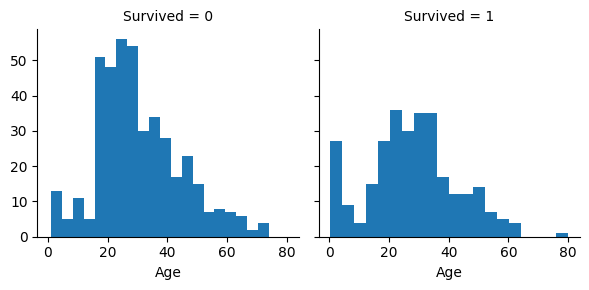

In [13]:
g = sns.FacetGrid(train_df, col='Survived')
g.map(plt.hist, 'Age', bins=20)

### Correlating numerical and ordinal features

The code creates a grid of subplots based on the 'Survived' and 'Pclass' columns in the 'train_df' DataFrame. It maps a histogram of the 'Age' variable onto each subplot, with transparency and 20 bins, and adds a legend to the grid.






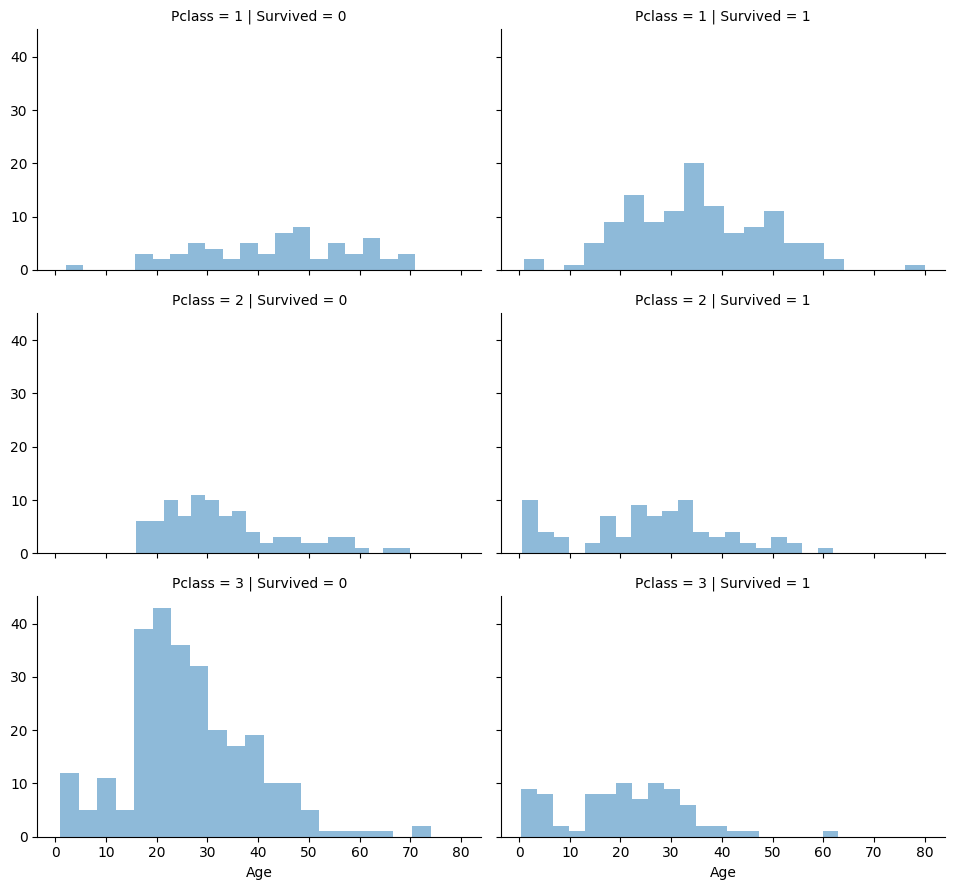

In [14]:
# grid = sns.FacetGrid(train_df, col='Pclass', hue='Survived')
grid = sns.FacetGrid(train_df, col='Survived', row='Pclass', aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend();

### Correlating categorical features

The code creates a facet grid using seaborn to display multiple point plots. Each plot represents the relationship between the "Pclass" (passenger class), "Survived" (survival status), and "Sex" variables, grouped by the "Embarked" variable. The resulting grid of plots is then given a legend.






/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:712: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:717: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


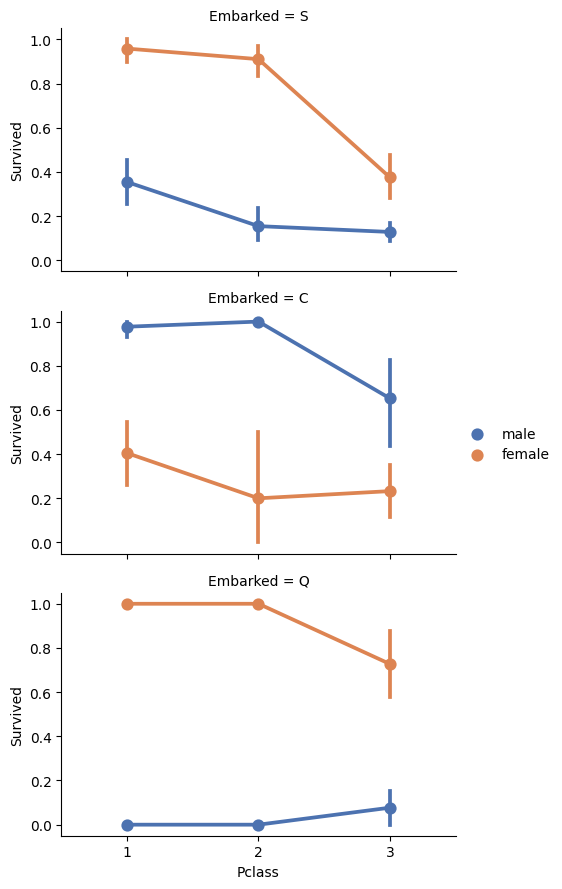

In [15]:
# grid = sns.FacetGrid(train_df, col='Embarked')
grid = sns.FacetGrid(train_df, row='Embarked', aspect=1.6)
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep')
grid.add_legend()

### Correlating categorical and numerical features

The code creates a facet grid using seaborn to display multiple bar plots. Each plot represents the relationship between the "Sex" and "Fare" variables, grouped by both the "Embarked" and "Survived" variables. The resulting grid of plots is then given a legend. The alpha value controls the transparency of the bars, and the ci parameter is set to None to disable error bars.






/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:712: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:848: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-pack

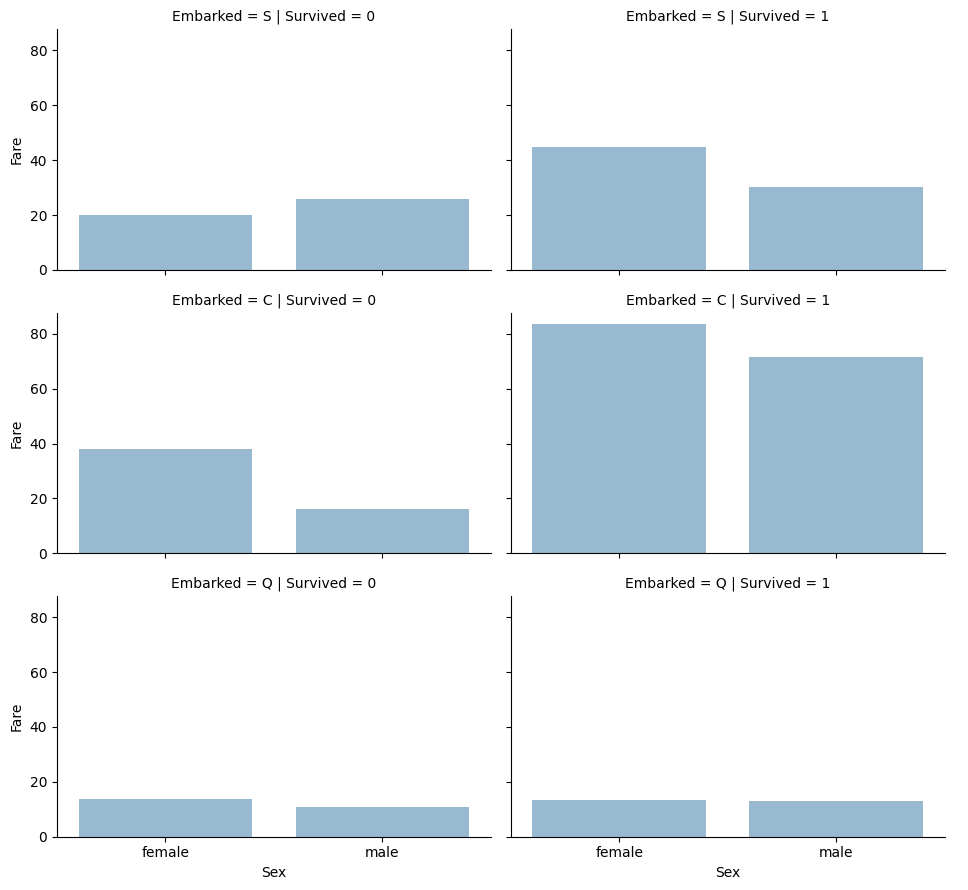

In [16]:
# grid = sns.FacetGrid(train_df, col='Embarked', hue='Survived', palette={0: 'k', 1: 'w'})
grid = sns.FacetGrid(train_df, row='Embarked', col='Survived', aspect=1.6)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()

## Wrangle data

The code prints the shape (number of rows and columns) of the "train_df," "test_df," and "combine" dataframes before and after dropping the 'Ticket' and 'Cabin' columns. The columns 'Ticket' and 'Cabin' are removed from both "train_df" and "test_df." Finally, the updated shapes of the dataframes are printed.






In [17]:
print("Before", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape)

train_df = train_df.drop(['Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin'], axis=1)
combine = [train_df, test_df]

"After", train_df.shape, test_df.shape, combine[0].shape, combine[1].shape

Before (891, 12) (418, 11) (891, 12) (418, 11)


('After', (891, 10), (418, 9), (891, 10), (418, 9))

### Creating new feature extracting from existing

The code iterates over each dataset in the "combine" list and adds a new column called 'Title' to each dataset. The 'Title' column is extracted from the 'Name' column using a regular expression pattern. Afterward, a cross-tabulation (crosstab) is performed on the 'Title' and 'Sex' columns of the "train_df" dataframe, showing the frequency count of each title by gender.






In [18]:
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

pd.crosstab(train_df['Title'], train_df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


The code replaces certain values in the 'Title' column of each dataset in the "combine" list. It replaces uncommon titles with 'Rare' and maps specific titles like 'Mlle', 'Ms', and 'Mme' to 'Miss' and 'Mrs' respectively. Finally, it calculates the mean survival rate grouped by 'Title' in the 'train_df' dataframe, showing the average survival rate for each title.






In [19]:
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col',\
 	'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

train_df[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


The code creates a dictionary called "title_mapping" to map specific titles to numerical values. It then maps the values from the 'Title' column of each dataset in the "combine" list using the "title_mapping" dictionary, replaces missing values with 0, and updates the 'Title' column accordingly. Finally, it displays the first few rows of the updated "train_df" dataframe.






In [20]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,3
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,3
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1


The code drops the 'Name' and 'PassengerId' columns from the "train_df" dataframe and the 'Name' column from the "test_df" dataframe. It then updates the "combine" list with the modified dataframes and prints the shapes (number of rows and columns) of the "train_df" and "test_df" dataframes.






In [21]:
train_df = train_df.drop(['Name', 'PassengerId'], axis=1)
test_df = test_df.drop(['Name'], axis=1)
combine = [train_df, test_df]
train_df.shape, test_df.shape

((891, 9), (418, 9))

### Converting a categorical feature

The code maps the values in the 'Sex' column of each dataset in the "combine" list, replacing 'female' with 1 and 'male' with 0. It then updates the 'Sex' column of the "train_df" dataframe accordingly and displays the first few rows of the updated dataframe.






In [22]:
for dataset in combine:
    dataset['Sex'] = dataset['Sex'].map( {'female': 1, 'male': 0} ).astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22.0,1,0,7.2500,S,1
1,1,1,1,38.0,1,0,71.2833,C,3
2,1,3,1,26.0,0,0,7.9250,S,2
3,1,1,1,35.0,1,0,53.1000,S,3
4,0,3,0,35.0,0,0,8.0500,S,1


### Completing a numerical continuous feature

The code creates a facet grid using seaborn to display multiple histograms. Each histogram represents the distribution of ages for different combinations of passenger class ('Pclass') and gender ('Sex'). The resulting grid of histograms is then given a legend. The 'alpha' parameter controls the transparency of the histograms, and 'bins' specifies the number of bins for the age distribution.






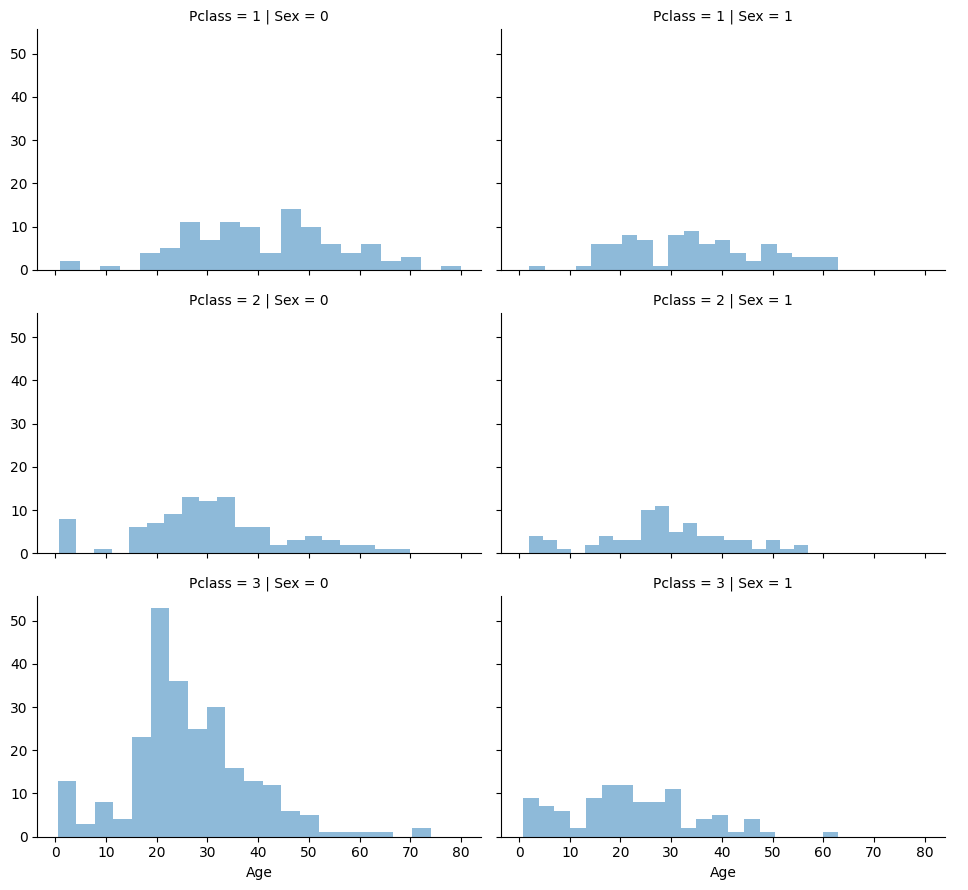

In [23]:
# grid = sns.FacetGrid(train_df, col='Pclass', hue='Gender')
grid = sns.FacetGrid(train_df, row='Pclass', col='Sex', aspect=1.6)
grid.map(plt.hist, 'Age', alpha=.5, bins=20)
grid.add_legend()

The code initializes a 2x3 array called "guess_ages" filled with zeros. The array is likely intended to store guessed ages based on certain criteria or calculations for different groups of individuals.






In [24]:
guess_ages = np.zeros((2,3))
guess_ages

array([[0., 0., 0.],
       [0., 0., 0.]])

The code estimates missing age values in the "Age" column of each dataset in the "combine" list. It does this by iterating through different combinations of gender ('Sex') and passenger class ('Pclass'), extracting non-null age values, calculating the median age, and storing it in the "guess_ages" array. Then, it assigns these estimated ages to the corresponding missing values in the "Age" column of each dataset. Finally, it converts the "Age" column to integers and displays the first few rows of the "train_df" dataframe.






In [25]:
for dataset in combine:
    for i in range(0, 2):
        for j in range(0, 3):
            guess_df = dataset[(dataset['Sex'] == i) & \
                                  (dataset['Pclass'] == j+1)]['Age'].dropna()

            # age_mean = guess_df.mean()
            # age_std = guess_df.std()
            # age_guess = rnd.uniform(age_mean - age_std, age_mean + age_std)

            age_guess = guess_df.median()

            # Convert random age float to nearest .5 age
            guess_ages[i,j] = int( age_guess/0.5 + 0.5 ) * 0.5

    for i in range(0, 2):
        for j in range(0, 3):
            dataset.loc[ (dataset.Age.isnull()) & (dataset.Sex == i) & (dataset.Pclass == j+1),\
                    'Age'] = guess_ages[i,j]

    dataset['Age'] = dataset['Age'].astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,22,1,0,7.2500,S,1
1,1,1,1,38,1,0,71.2833,C,3
2,1,3,1,26,0,0,7.9250,S,2
3,1,1,1,35,1,0,53.1000,S,3
4,0,3,0,35,0,0,8.0500,S,1


The code creates an 'AgeBand' column in the "train_df" dataframe by dividing the 'Age' column into five equal-width bins. It then groups the data by 'AgeBand', calculates the average survival rate for each age band, and sorts the results in ascending order of 'AgeBand'.






In [26]:
train_df['AgeBand'] = pd.cut(train_df['Age'], 5)
train_df[['AgeBand', 'Survived']].groupby(['AgeBand'], as_index=False).mean().sort_values(by='AgeBand', ascending=True)

,AgeBand,Survived
0,"(-0.08, 16.0]",0.550000
1,"(16.0, 32.0]",0.337374
2,"(32.0, 48.0]",0.412037
3,"(48.0, 64.0]",0.434783
4,"(64.0, 80.0]",0.090909


The code categorizes the 'Age' values in each dataset in the "combine" list into different age groups. It assigns the value 0 to ages <= 16, 1 to ages between 16 and 32, 2 to ages between 32 and 48, 3 to ages between 48 and 64, and leaves ages > 64 unchanged. Finally, it displays the first few rows of the updated "train_df" dataframe.






In [27]:
for dataset in combine:
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 32), 'Age'] = 1
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48), 'Age'] = 2
    dataset.loc[(dataset['Age'] > 48) & (dataset['Age'] <= 64), 'Age'] = 3
    dataset.loc[ dataset['Age'] > 64, 'Age']
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeBand
0,0,3,0,1,1,0,7.2500,S,1,"(16.0, 32.0]"
1,1,1,1,2,1,0,71.2833,C,3,"(32.0, 48.0]"
2,1,3,1,1,0,0,7.9250,S,2,"(16.0, 32.0]"
3,1,1,1,2,1,0,53.1000,S,3,"(32.0, 48.0]"
4,0,3,0,2,0,0,8.0500,S,1,"(32.0, 48.0]"


The code drops the 'AgeBand' column from the "train_df" dataframe. It then updates the "combine" list with the modified "train_df" and "test_df" dataframes. Finally, it displays the first few rows of the updated "train_df" dataframe.






In [28]:
train_df = train_df.drop(['AgeBand'], axis=1)
combine = [train_df, test_df]
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,0,1,1,0,7.2500,S,1
1,1,1,1,2,1,0,71.2833,C,3
2,1,3,1,1,0,0,7.9250,S,2
3,1,1,1,2,1,0,53.1000,S,3
4,0,3,0,2,0,0,8.0500,S,1


### Create new feature combining existing features

The code creates a new 'FamilySize' column in each dataset of the "combine" list by summing the 'SibSp' (number of siblings/spouses) and 'Parch' (number of parents/children) columns, and adding 1 to include the individual themselves. It then groups the data by 'FamilySize', calculates the average survival rate for each family size, and sorts the results in descending order of survival rate.






In [29]:
for dataset in combine:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

train_df[['FamilySize', 'Survived']].groupby(['FamilySize'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,FamilySize,Survived
3,4,0.724138
2,3,0.578431
1,2,0.552795
6,7,0.333333
0,1,0.303538
4,5,0.200000
5,6,0.136364
7,8,0.000000
8,11,0.000000


The code creates a new binary column called 'IsAlone' in each dataset of the "combine" list. It assigns a value of 1 to individuals who have a family size of 1 (indicating they are alone) and 0 otherwise. It then groups the data by 'IsAlone' and calculates the average survival rate for each group.






In [30]:
for dataset in combine:
    dataset['IsAlone'] = 0
    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1

train_df[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


The code drops the 'Parch', 'SibSp', and 'FamilySize' columns from the "train_df" and "test_df" dataframes. It updates the "combine" list with the modified dataframes and then displays the first few rows of the updated "train_df" dataframe.






In [31]:
train_df = train_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
test_df = test_df.drop(['Parch', 'SibSp', 'FamilySize'], axis=1)
combine = [train_df, test_df]

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,0,3,0,1,7.2500,S,1,0
1,1,1,1,2,71.2833,C,3,0
2,1,3,1,1,7.9250,S,2,1
3,1,1,1,2,53.1000,S,3,0
4,0,3,0,2,8.0500,S,1,1


The code creates a new column called 'AgeClass' in each dataset of the "combine" list by multiplying the 'Age' column with the 'Pclass' column. It then displays the 'AgeClass', 'Age', and 'Pclass' columns of the first 10 rows in the "train_df" dataframe.






In [32]:
for dataset in combine:
    dataset['Age*Class'] = dataset.Age * dataset.Pclass

train_df.loc[:, ['Age*Class', 'Age', 'Pclass']].head(10)

,Age*Class,Age,Pclass
0,3,1,3
1,2,2,1
2,3,1,3
3,2,2,1
4,6,2,3
5,3,1,3
6,3,3,1
7,0,0,3
8,3,1,3
9,0,0,2


### Completing a categorical feature

The code identifies the most frequently occurring value in the 'Embarked' column of the "train_df" dataframe by dropping any missing values, finding the mode, and selecting the first value from the resulting mode array. It then assigns this most frequent value to the variable 'freq_port'.






In [33]:
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

The code fills the missing values in the 'Embarked' column of each dataset in the "combine" list with the most frequent value, 'freq_port'. It then groups the data by 'Embarked', calculates the average survival rate for each port of embarkation, and sorts the results in descending order of survival rate.






In [34]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port)

train_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


### Converting categorical feature to numeric

The code maps the values in the 'Embarked' column of each dataset in the "combine" list, replacing 'S' with 0, 'C' with 1, and 'Q' with 2. It then updates the 'Embarked' column of the "train_df" dataframe accordingly and displays the first few rows of the updated dataframe.






In [35]:
for dataset in combine:
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int)

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,0,1,7.2500,0,1,0,3
1,1,1,1,2,71.2833,1,3,0,2
2,1,3,1,1,7.9250,0,2,1,3
3,1,1,1,2,53.1000,0,3,0,2
4,0,3,0,2,8.0500,0,1,1,6


### Quick completing and converting a numeric feature
The code fills the missing values in the 'Fare' column of the "test_df" dataframe with the median value of the non-missing fare values. It then displays the first few rows of the updated "test_df" dataframe.






In [36]:
test_df['Fare'].fillna(test_df['Fare'].dropna().median(), inplace=True)
test_df.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,892,3,0,2,7.8292,2,1,1,6
1,893,3,1,2,7.0000,0,3,0,6
2,894,2,0,3,9.6875,2,1,1,6
3,895,3,0,1,8.6625,0,1,1,3
4,896,3,1,1,12.2875,0,3,0,3


The code creates a new column called 'FareBand' in the "train_df" dataframe by dividing the 'Fare' column into four equal-sized bins based on quantiles (qcut). It then groups the data by 'FareBand', calculates the average survival rate for each fare band, and sorts the results in ascending order of 'FareBand'.






In [37]:
train_df['FareBand'] = pd.qcut(train_df['Fare'], 4)
train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index=False).mean().sort_values(by='FareBand', ascending=True)

,FareBand,Survived
0,"(-0.001, 7.91]",0.197309
1,"(7.91, 14.454]",0.303571
2,"(14.454, 31.0]",0.454955
3,"(31.0, 512.329]",0.581081


The code categorizes the 'Fare' values in each dataset of the "combine" list into different fare groups. It assigns the value 0 to fares <= 7.91, 1 to fares between 7.91 and 14.454, 2 to fares between 14.454 and 31, and 3 to fares > 31. It then converts the 'Fare' column to integers. Afterward, it drops the 'FareBand' column from the "train_df" dataframe, updates the "combine" list, and displays the first 10 rows of the updated "train_df" dataframe.






In [38]:
for dataset in combine:
    dataset.loc[ dataset['Fare'] <= 7.91, 'Fare'] = 0
    dataset.loc[(dataset['Fare'] > 7.91) & (dataset['Fare'] <= 14.454), 'Fare'] = 1
    dataset.loc[(dataset['Fare'] > 14.454) & (dataset['Fare'] <= 31), 'Fare']   = 2
    dataset.loc[ dataset['Fare'] > 31, 'Fare'] = 3
    dataset['Fare'] = dataset['Fare'].astype(int)

train_df = train_df.drop(['FareBand'], axis=1)
combine = [train_df, test_df]

train_df.head(10)

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,0,1,0,0,1,0,3
1,1,1,1,2,3,1,3,0,2
2,1,3,1,1,1,0,2,1,3
3,1,1,1,2,3,0,3,0,2
4,0,3,0,2,1,0,1,1,6
5,0,3,0,1,1,2,1,1,3
6,0,1,0,3,3,0,1,1,3
7,0,3,0,0,2,0,4,0,0
8,1,3,1,1,1,0,3,0,3
9,1,2,1,0,2,1,3,0,0


In [39]:
test_df.head(10)

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,892,3,0,2,0,2,1,1,6
1,893,3,1,2,0,0,3,0,6
2,894,2,0,3,1,2,1,1,6
3,895,3,0,1,1,0,1,1,3
4,896,3,1,1,1,0,3,0,3
5,897,3,0,0,1,0,1,1,0
6,898,3,1,1,0,2,2,1,3
7,899,2,0,1,2,0,1,0,2
8,900,3,1,1,0,1,3,1,3
9,901,3,0,1,2,0,1,0,3


## Model, predict and solve

The code prepares the training and test datasets for the machine learning model. It creates the "X_train" dataframe by dropping the "Survived" column from the "train_df" dataframe, assigns the "Survived" column to the "Y_train" variable, and creates the "X_test" dataframe by dropping the "PassengerId" column from the "test_df" dataframe. The code then prints the shapes of the "X_train," "Y_train," and "X_test" datasets, indicating the number of rows and columns in each dataset.






In [40]:
X_train = train_df.drop("Survived", axis=1)
Y_train = train_df["Survived"]
X_test  = test_df.drop("PassengerId", axis=1).copy()
X_train.shape, Y_train.shape, X_test.shape

((891, 8), (891,), (418, 8))

---
## Prepare Data for Modeling


In [ ]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

# Handle non-numeric columns for modeling
X = pd.get_dummies(X, drop_first=True)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


---
## Step 1: Baseline Model Comparison (LazyPredict)

Quick automated comparison of multiple models to establish baselines.


In [ ]:
from lazypredict.Supervised import LazyClassifier

lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

print(models)


---
## Step 2: Final Pipeline (PyCaret)

Automated ML pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.classification import *

clf_setup = setup(data=df, target='Survived', session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Evaluate the best model
evaluate_model(best_model)


In [ ]:
# Finalize the model (train on full dataset)
final_model = finalize_model(best_model)

print('Final model:', final_model)